"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

In [1]:
""" Exercise 4: NumPy Array Operations Complete the following tasks using NumPy. """

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
import numpy as np
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
print(matrix)
# Hint: Use np.ones and array slicing

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [2]:
# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized.mean(axis=0))
print(normalized.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


In [3]:
# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta_hat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
# TODO: Print the estimated coefficients and compare with true_theta
print("Estimated theta:", theta_hat)
print("True theta:", true_theta)

Estimated theta: [-0.01035573  2.51756955 -1.19800274  3.72573182]
True theta: [ 2.5 -1.2  3.7]


In [4]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""
import pandas as pd

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print(df.info())
print(df.describe())
# TODO: Identify and count missing values
print("Missing values:", df.isnull().sum())
# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean()))
# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median()))


# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
print(df.groupby('major')['exam_score'].mean())
# TODO: Find the major with the highest average exam_score
print("Highest major:", df.groupby('major')['exam_score'].mean().idxmax())
# TODO: Calculate the correlation between hours_studied and exam_score
print("Correlation:", df['hours_studied'].corr(df['exam_score']))
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df['performance'] = pd.cut(
    df['exam_score'], bins=[-np.inf, 70, 80, 90, np.inf], labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])
print(df[['exam_score', 'performance']].head())


# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
result = df.groupby(['major', 'year']).agg(
    Num_Stud=('student_id', 'count'),
    Avg_exam_score=('exam_score', 'mean'),
    Avg_hours_studied=('hours_studied', 'mean'))
print(result)
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_students = df.nlargest(5, 'exam_score')
print(top_students[['student_id', 'exam_score']])
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
Pivot_Table = pd.pivot_table(df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean')
print(Pivot_Table)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

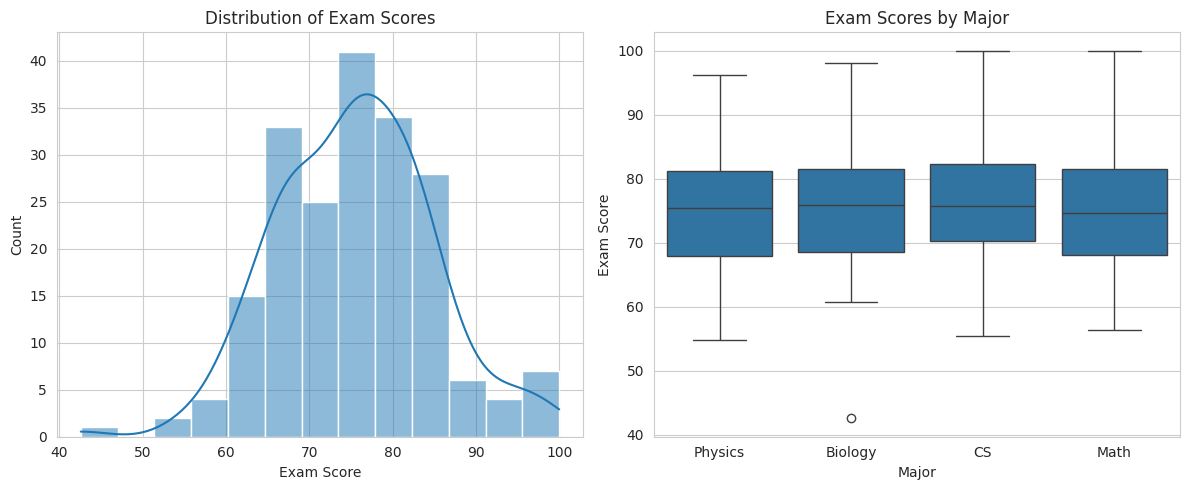

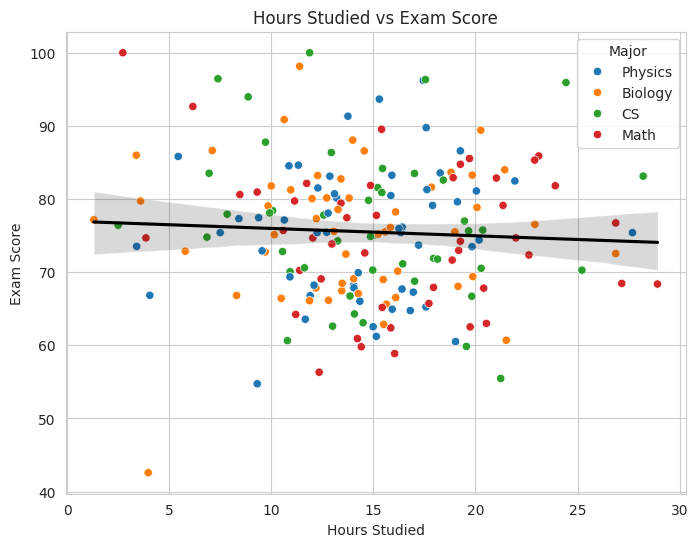

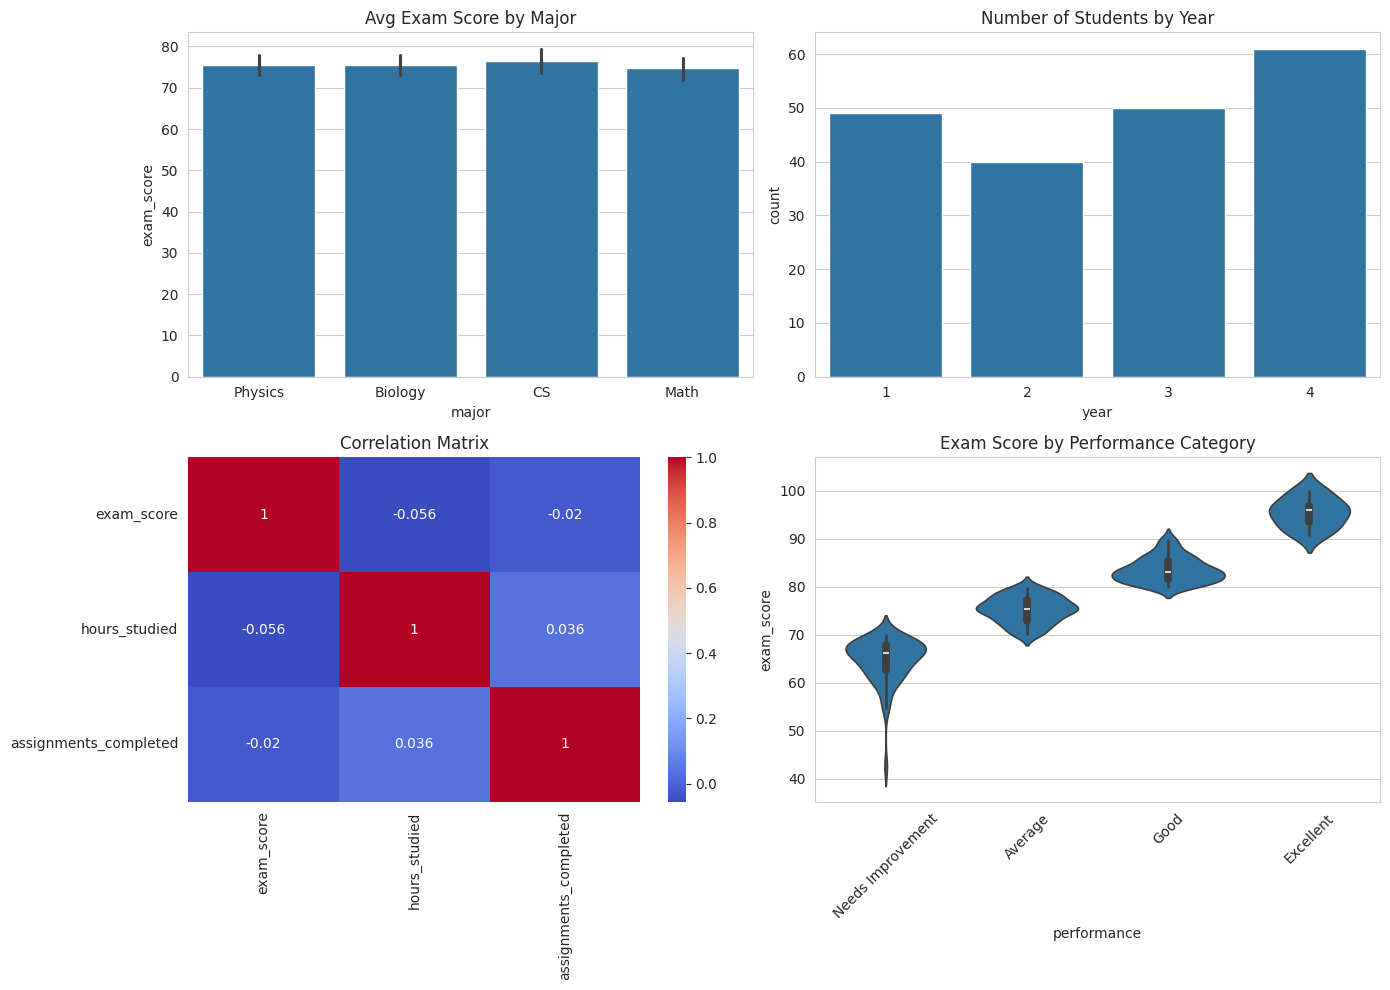

In [5]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")

#       Right: Box plot of exam scores by major
sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major')
# TODO: Color points by major

# TODO: Add a regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black')
# TODO: Include appropriate legends, titles, and axis labels
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(
    x='major',
    y='exam_score',
    data=df,
    ax=axes[0, 0])
axes[0, 0].set_title("Avg Exam Score by Major")
sns.countplot(
    x='year',
    data=df,
    ax=axes[0, 1])
axes[0, 1].set_title("Number of Students by Year")
corr = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title("Correlation Matrix")
sns.violinplot(
    x='performance',
    y='exam_score',
    data=df,
    ax=axes[1, 1])
# TODO: Adjust layout, add titles, and ensure readability
axes[1, 1].set_title("Exam Score by Performance Category")
axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           CLV  
0   937.397271  
1   370.085023  
2   418.424348  
3   477.171887  
4  1097.651683  
   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70
           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70    

/tmp/ipykernel_26395/55355483.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = customers.groupby('age_group').agg(


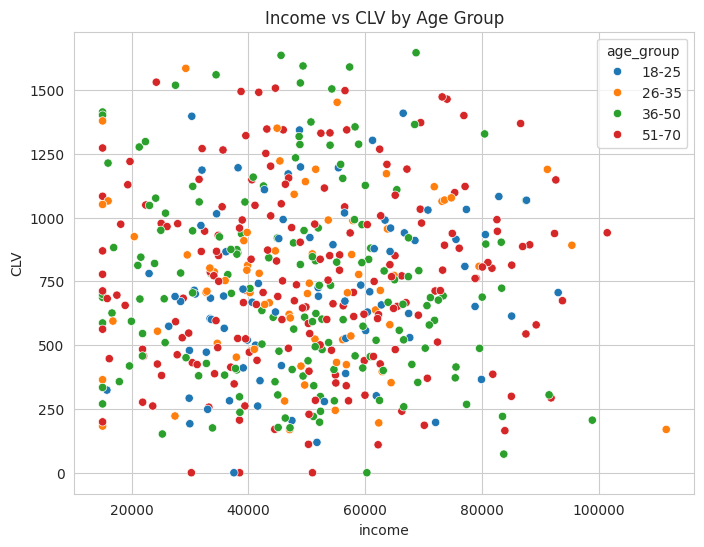

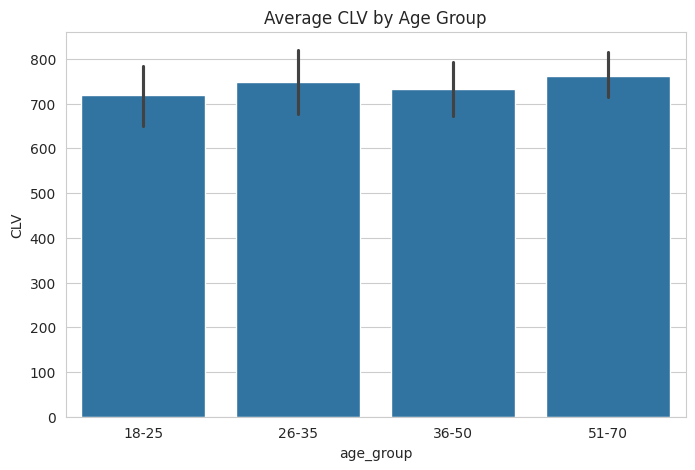

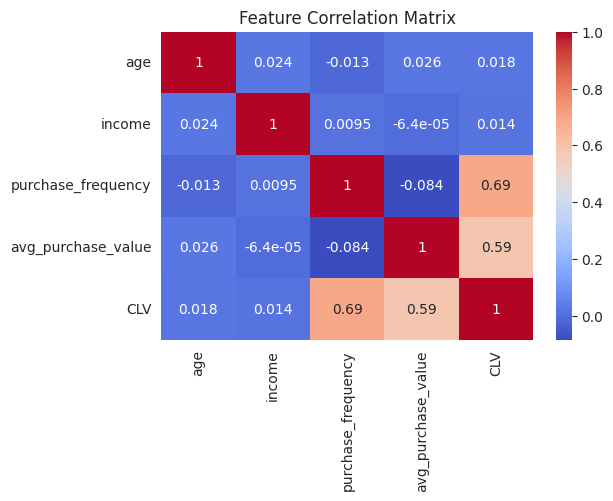

'Mjority of the age group that earn middle income fairly contribut moderately to the CLV and the few with high income accross in the 26 to 70 age group contributes to a smaller amount of the CLV.\nThe custmers between the ages of 26 to 35 are those with high purchasing records.\n- Recommendation: Maketing should be focused on customers that are between the ages of 26 to 35 years of age.'

In [6]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = (
    customers['purchase_frequency'] *
    customers['avg_purchase_value'] *
    (1 + customers['churn_risk']))
print(customers.head())
# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)
print(customers[['age', 'age_group']].head())

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_analysis = customers.groupby('age_group').agg(
    num_customers=('CLV', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum'))
print(age_analysis)

# TODO: Identify top 10% of customers by CLV
threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]
print("Top 10% customers:")
print(top_customers[['age', 'income', 'CLV']].head())

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group')
plt.title("Income vs CLV by Age Group")
plt.show()
plt.figure(figsize=(8,5))
sns.barplot(
    data=customers,
    x='age_group',
    y='CLV')
plt.title("Average CLV by Age Group")
plt.show()

plt.figure(figsize=(6,4))
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
"""Mjority of the age group that earn middle income fairly contribut moderately to the CLV and the few with high income accross in the 26 to 70 age group contributes to a smaller amount of the CLV.
The custmers between the ages of 26 to 35 are those with high purchasing records.
- Recommendation: Maketing should be focused on customers that are between the ages of 26 to 35 years of age."""